In [1]:
import serial
import numpy as np
import json
import time
import matplotlib.pyplot as plt

In [38]:
!ls /dev/ttyUSB*

/dev/ttyUSB1


In [82]:
ser = serial.Serial('/dev/ttyUSB1', baudrate=115200, rtscts=True)

In [69]:
messages = b"""\
{xvm:3000}
{yvm:3000}
{xjm:2500}
{yjm:2500}
"""

# messages = b"""\
# {xvm:n}
# {yvm:n}
# {xjm:n}
# {yjm:n}
# """

# messages = b"""\
# {1mi:4}
# {2mi:4}
# {3mi:4}
# """

for msg in messages.splitlines():
    ser.write(msg + b'\n')
    print(ser.read_until())

b'{"r":{},"f":[1,0,19,78]}\n'
b'{"r":{},"f":[1,0,19,78]}\n'
b'{"r":{},"f":[1,0,19,78]}\n'
b'{"r":{"xvm":3000},"f":[1,0,11,9303]}\n'


In [84]:
ser.write(b'!%')

2

In [87]:
ser.write(b'g10l2p1x-50y-65\n')

16

In [113]:
try:
    while True:
        print(ser.read_until())
except:
    pass

b'{"r":{},"f":[1,0,7,4400]}\n'
b'{"r":{},"f":[1,0,7,4400]}\n'
b'{"r":{},"f":[1,0,8,4401]}\n'
b'{"r":{},"f":[1,0,8,4401]}\n'
b'{"r":{},"f":[1,0,9,4402]}\n'
b'{"r":{},"f":[1,0,9,4402]}\n'
b'{"r":{},"f":[1,0,9,4402]}\n'
b'{"r":{},"f":[1,0,9,4402]}\n'
b'{"rx":254}\n'
b'r"{f"090"b:4.0"p:,v:,i""U58TX,mg:SSE ED",f:10074]\n'
b'r"v:.7,f"402,h"1"v:,i""U58TX,mg:SSE ED",f:10074]\n'


In [112]:
for i in range(8):
    msg = f'g0x{i*7}y{i*3}'
    print(msg)
    ser.write(msg.encode('ascii') + b'\n')
ser.write(b'!%')

g0x0y0
g0x7y3
g0x14y6
g0x21y9
g0x28y12
g0x35y15
g0x42y18
g0x49y21


2

In [83]:
ser.write(chr(24).encode('ascii')) # reset
ser.read_until()

b'{"r":{"fv":0.970,"fb":440.20,"hp":1,"hv":8,"id":"9U6538-TTX","msg":"SYSTEM READY"},"f":[1,0,0,7841]}\n'

In [114]:
ser.close()

In [4]:
def generate_circle(x, y, r, n=256):
    thetas = np.linspace(0, 2 * np.pi, n)
    points = []
    for theta in thetas:
        xx = x + np.cos(theta) * r
        yy = y + np.sin(theta) * r
        points.append((xx,yy))
    return points

# accuracy seems to make little difference
# 3-5 points of accuracy is fine. less causes aliasing in motion planning
def points_to_gcode(points):
    gcode = []
    for x,y in points:
        line = f'g0x{x:.4f}y{y:.4f}'
        gcode.append(line)
    return '\n'.join(gcode)

# 256 and 10mm radius is too much (0.245 / step)
# 200 and 10mm radius is fine (0.314 / step)
# 300 and 20mm radius is too much (0.418 / step) (?) motion planning stalls?
# 256 and 20mm radius is fine (0.491 / step)
radius = 20
n = 128
points = generate_circle(0, 0, radius, n)
points = np.vstack((points, points))
points = np.vstack((points, [[0,0]]))
circle = points_to_gcode(points)
2 * np.pi * radius / n, 'per step'

(0.9817477042468103, 'per step')

In [5]:
"""
https://github.com/synthetos/TinyG/wiki/Tinyg-Communications-Programming
The protocol is simple - "blast" 4 command lines to the board without waiting for responses.
From that point on send a single line for every {r:...} response received.
Every command will return one and only one response.
"""
gcode = circle
# def send_gcode(ser, gcode):

cmds = gcode.split('\n')
buffer_size = 4
buffer_total = 0
buffer_history = []
timing = []
msgs = [cmd.encode('ascii') + b'\n' for cmd in cmds]

for msg in msgs[:buffer_size]:
    timing.append(time.time())
    ser.write(msg)
    buffer_total += len(msg)
    buffer_history.append(buffer_total)

for i, msg in enumerate(msgs[buffer_size:]):
    timing.append(time.time())
    ser.write(msg)
    buffer_total += len(msg)
    buffer_history.append(buffer_total)

    response = ser.read_until()
    buffer_total -= json.loads(response)['f'][2]
    buffer_history.append(buffer_total)
    
    if i >= 100:
        ser.write(b'!')
        break

for i in range(buffer_size):
    response = ser.read_until()
    buffer_total -= json.loads(response)['f'][2]
    buffer_history.append(buffer_total)

#     return timing, buffer_history
        
# timing, buffer_history = send_gcode(ser, circle)

SerialException: read failed: device reports readiness to read but returned no data (device disconnected or multiple access on port?)

In [15]:
ser.write(b'%')
# ser.read_until()

2

In [16]:
ser.read_until()

b'{"rx":252}\n'

In [30]:
# from serial.tools import list_ports
# try:
#     port = next(list_ports.grep('USB Serial'))
#     port = port.device
# except StopIteration:
#     port = None
    
for port in list_ports.grep('FT230X'):
    print(port)

/dev/ttyUSB0 - FT230X Basic UART


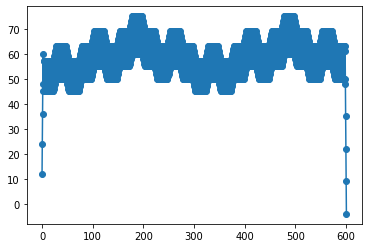

In [185]:
x = np.linspace(0, len(timing), len(buffer_history))
plt.plot(x, buffer_history)
plt.scatter(x, buffer_history)
plt.show()

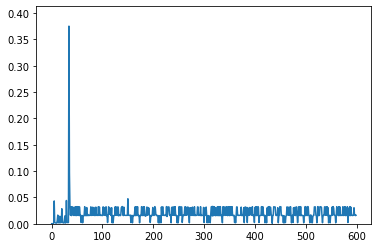

In [186]:
y = np.diff(timing)
plt.plot(y)
plt.ylim(0, np.max(y) * 1.1)
plt.show()

In [15]:
ser.write(b'g0x-70y0\n')

9

In [24]:
# ser.write(b'?\n')
ser.write(b'{sr:n}\n')

7

In [4]:
import time
buffer_size = 0
try:
    while True:
        e = ser.read_until()
        print(e)
        buffer_size += len(e)
        time.sleep(0.01)
        print(buffer_size)
except:
    pass

In [23]:
ser.write(b'g10l2p1x-50y-35\n')

16

In [17]:
ser.write(b'g53\n')

4